# 🎬 Amazon Prime — Notebook 2: Exploratory Data Analysis (EDA)

**Objective:** Explore the cleaned dataset to discover patterns, distributions, and key insights about Amazon Prime's content library.

---

## 1️⃣ Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Color palette (Amazon Prime theme)
PRIME_BLUE  = '#00A8E0'
PRIME_DARK  = '#0F2027'
PRIME_TEAL  = '#1DB954'
PALETTE     = [PRIME_BLUE, '#FF9900', '#E50914', '#00C853', '#AA00FF', '#FF6D00', '#0288D1', '#AD1457']

# Plot styling
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F9F9F9',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11
})

df = pd.read_csv('../data/processed/amazon_prime_cleaned.csv', parse_dates=['date_added'])
print(f'✅ Loaded: {df.shape[0]} rows × {df.shape[1]} columns')

✅ Loaded: 155 rows × 20 columns


## 2️⃣ Content Type Distribution — Movies vs TV Shows

In [2]:
type_counts = df['type'].value_counts()
print(type_counts)
print(f'\nMovie ratio  : {type_counts["Movie"]/len(df)*100:.1f}%')
print(f'TV Show ratio: {type_counts["TV Show"]/len(df)*100:.1f}%')

type
TV Show    139
Movie       16
Name: count, dtype: int64

Movie ratio  : 10.3%
TV Show ratio: 89.7%


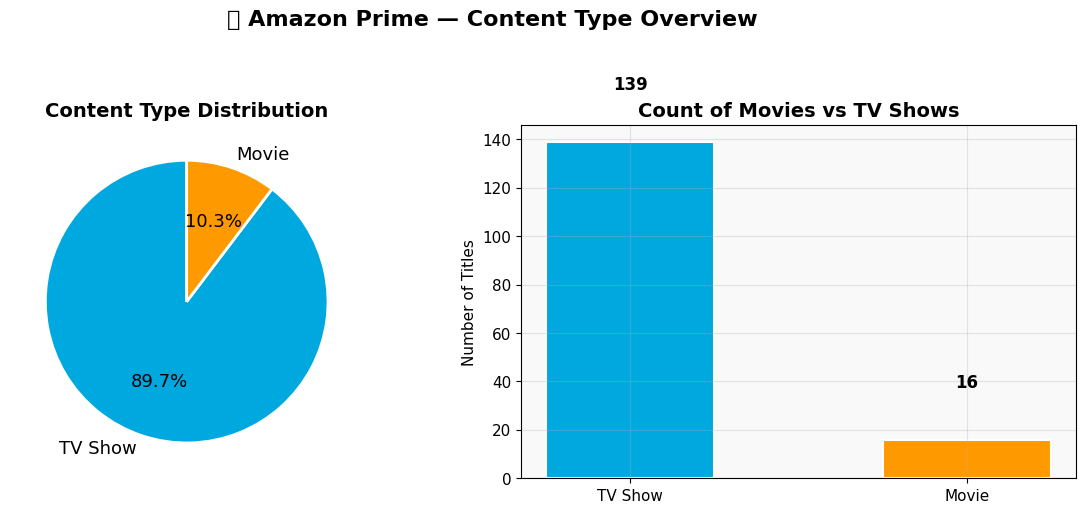

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
            colors=[PRIME_BLUE, '#FF9900'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2},
            textprops={'fontsize':13})
axes[0].set_title('Content Type Distribution', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[1].bar(type_counts.index, type_counts.values,
                   color=[PRIME_BLUE, '#FF9900'], edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, type_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[1].set_title('Count of Movies vs TV Shows', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Titles')

plt.suptitle('🎬 Amazon Prime — Content Type Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../visualizations/01_content_type.png', dpi=150, bbox_inches='tight')
plt.show()

## 3️⃣ Content Added Over the Years

In [4]:
yearly = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
print(yearly)

type        Movie  TV Show
year_added                
2021           16      139


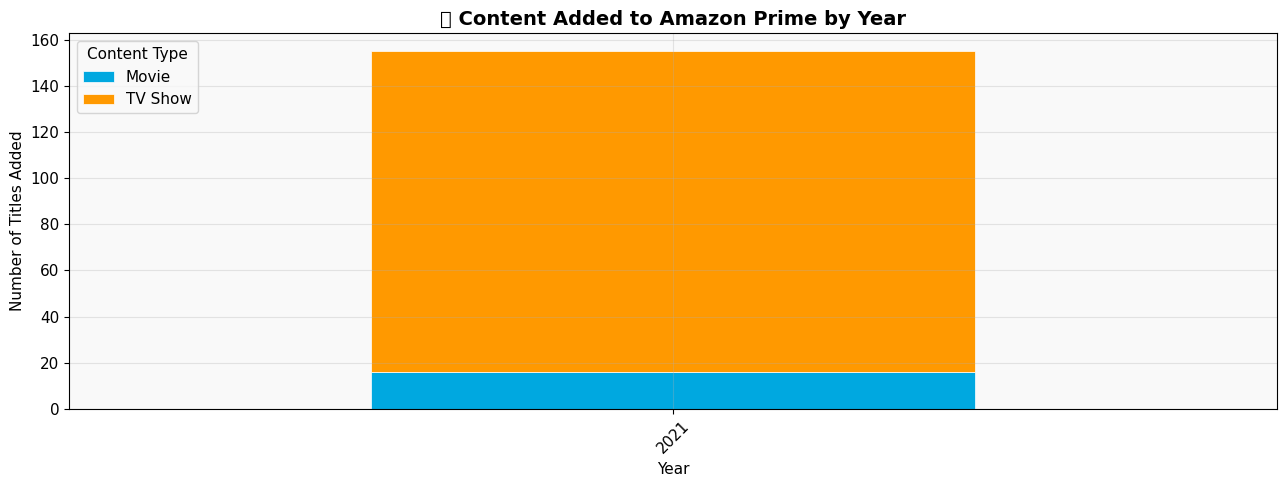

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))

yearly.plot(kind='bar', stacked=True, ax=ax,
            color=[PRIME_BLUE, '#FF9900'], edgecolor='white', linewidth=0.5)

ax.set_title('📅 Content Added to Amazon Prime by Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Titles Added')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.legend(title='Content Type', loc='upper left')

plt.tight_layout()
plt.savefig('../visualizations/02_content_yearly.png', dpi=150, bbox_inches='tight')
plt.show()

## 4️⃣ Monthly Content Addition Trend

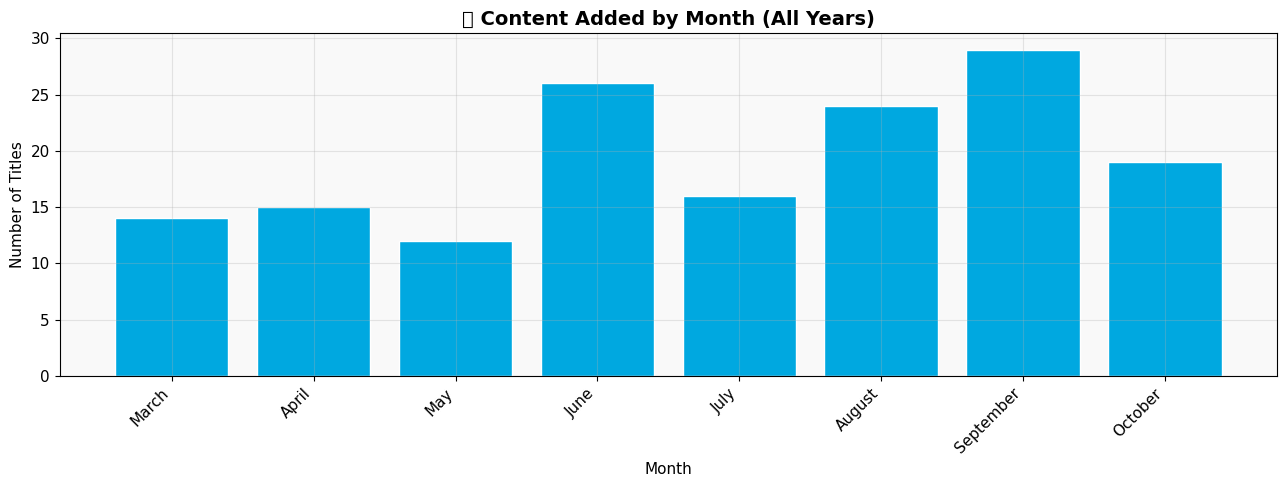

In [6]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly = df['month_name'].value_counts().reindex(month_order)

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(monthly.index, monthly.values, color=PRIME_BLUE, edgecolor='white')

# Highlight peak month
peak_idx = monthly.values.argmax()
bars[peak_idx].set_color('#FF9900')

ax.set_title('📆 Content Added by Month (All Years)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Titles')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../visualizations/03_monthly_additions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5️⃣ Top 15 Countries by Content Production

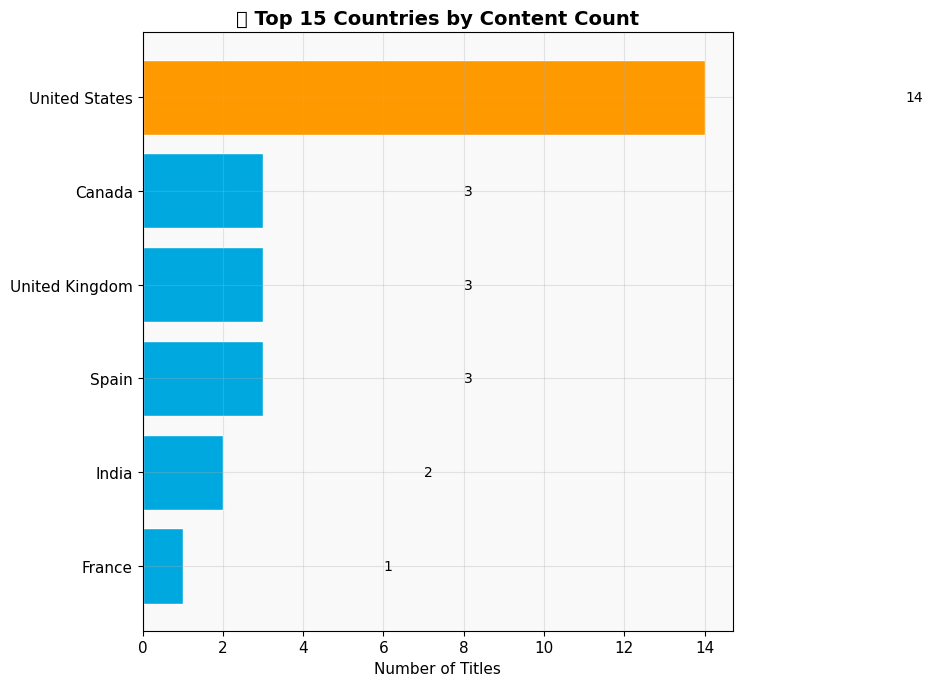

In [7]:
top_countries = (df[df['primary_country'] != 'Unknown']
                 ['primary_country'].value_counts().head(15))

fig, ax = plt.subplots(figsize=(10, 7))
colors = [PRIME_BLUE if i > 0 else '#FF9900' for i in range(len(top_countries))]
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1],
               color=colors[::-1], edgecolor='white')

for bar, val in zip(bars, top_countries.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)

ax.set_title('🌍 Top 15 Countries by Content Count', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Titles')
plt.tight_layout()
plt.savefig('../visualizations/04_top_countries.png', dpi=150, bbox_inches='tight')
plt.show()

## 6️⃣ Content Rating Analysis

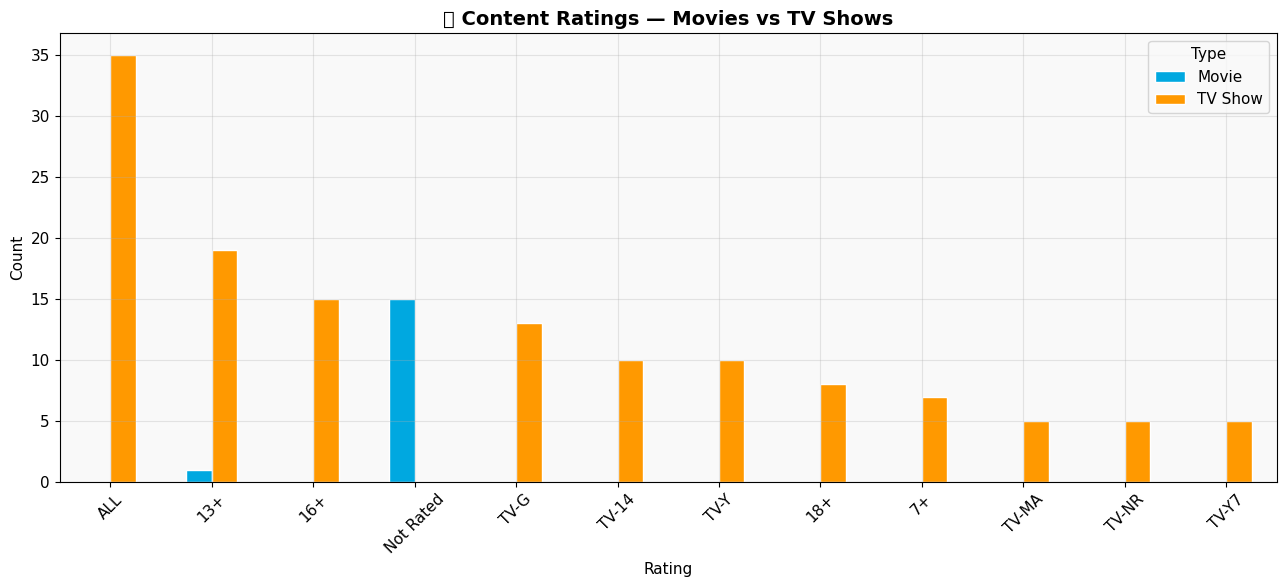

In [8]:
# Ratings across content types
rating_type = df.groupby(['rating', 'type']).size().unstack(fill_value=0)
rating_type['Total'] = rating_type.sum(axis=1)
rating_type = rating_type.sort_values('Total', ascending=False).head(12).drop('Total', axis=1)

fig, ax = plt.subplots(figsize=(13, 6))
rating_type.plot(kind='bar', ax=ax, color=[PRIME_BLUE, '#FF9900'], edgecolor='white')

ax.set_title('🔞 Content Ratings — Movies vs TV Shows', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.legend(title='Type')

plt.tight_layout()
plt.savefig('../visualizations/05_ratings.png', dpi=150, bbox_inches='tight')
plt.show()

## 7️⃣ Top Genres Analysis

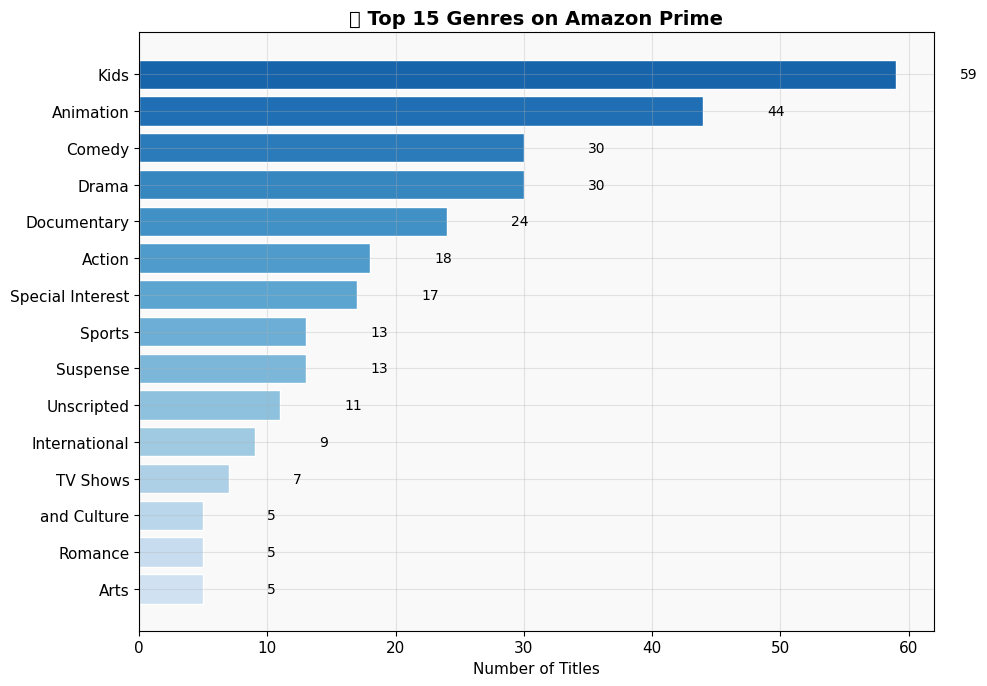

In [9]:
# Explode multi-genre listings
genre_series = df['listed_in'].str.split(',').explode().str.strip()
top_genres = genre_series.value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 7))
cmap_colors = plt.cm.Blues_r(np.linspace(0.2, 0.8, len(top_genres)))
bars = ax.barh(top_genres.index[::-1], top_genres.values[::-1],
               color=cmap_colors[::-1], edgecolor='white')

for bar, val in zip(bars, top_genres.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)

ax.set_title('🎭 Top 15 Genres on Amazon Prime', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Titles')
plt.tight_layout()
plt.savefig('../visualizations/06_top_genres.png', dpi=150, bbox_inches='tight')
plt.show()

## 8️⃣ Release Year Trend

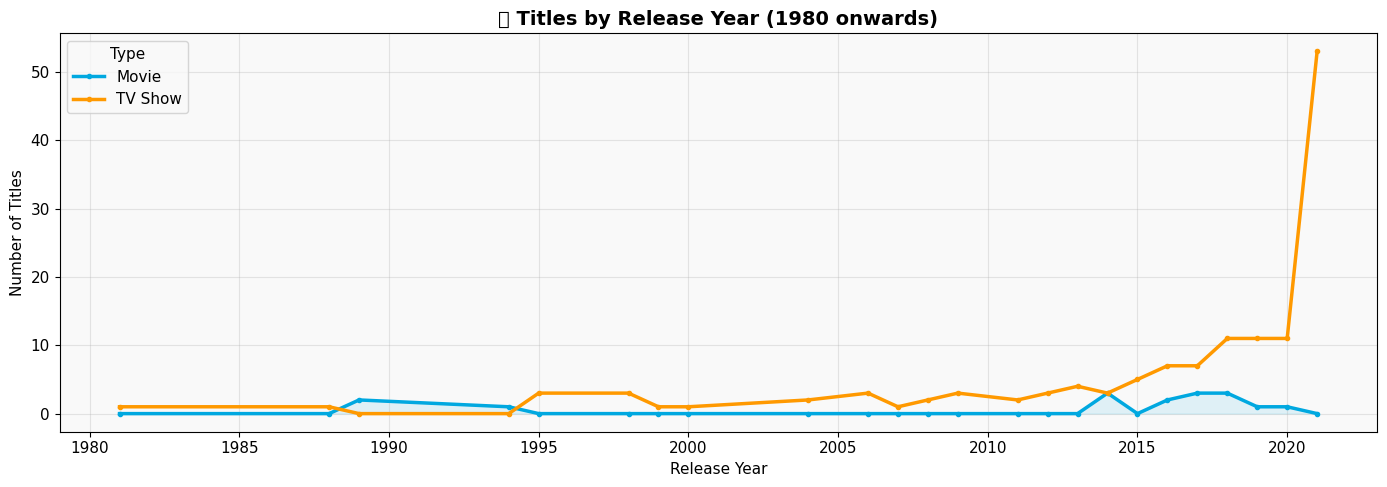

In [10]:
release = df[df['release_year'] >= 1980].groupby(['release_year', 'type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
release.plot(ax=ax, linewidth=2.5, color=[PRIME_BLUE, '#FF9900'], marker='o', markersize=3)

ax.set_title('📊 Titles by Release Year (1980 onwards)', fontsize=14, fontweight='bold')
ax.set_xlabel('Release Year')
ax.set_ylabel('Number of Titles')
ax.legend(title='Type')
ax.fill_between(release.index, release.get('Movie', 0), alpha=0.1, color=PRIME_BLUE)

plt.tight_layout()
plt.savefig('../visualizations/07_release_year.png', dpi=150, bbox_inches='tight')
plt.show()

## 9️⃣ Movie Duration Distribution

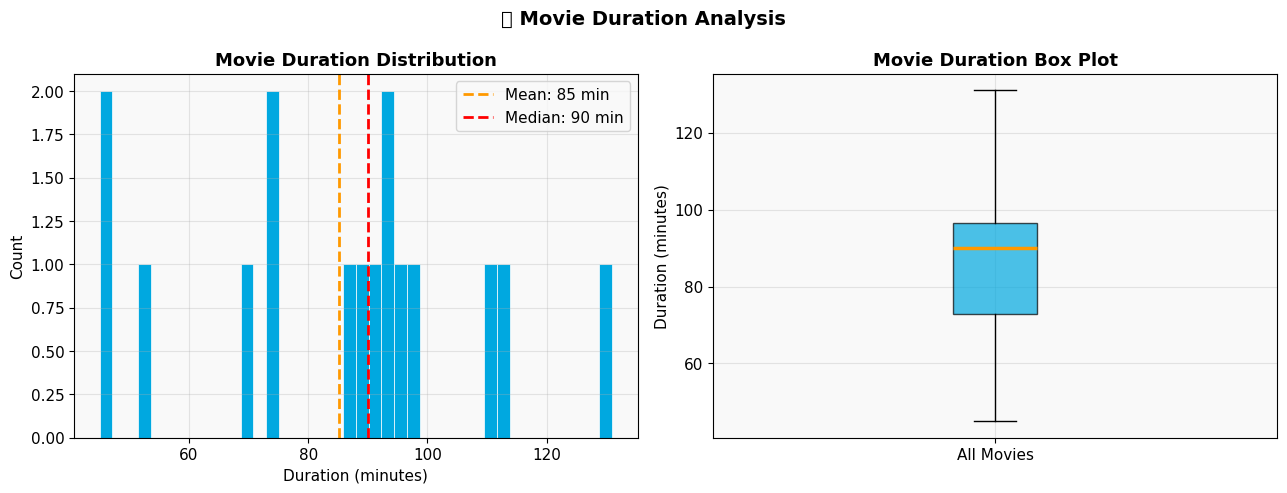

In [11]:
movies = df[(df['type'] == 'Movie') & (df['duration_int'].notna())]
movies = movies[(movies['duration_int'] > 20) & (movies['duration_int'] < 300)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
axes[0].hist(movies['duration_int'], bins=40, color=PRIME_BLUE,
             edgecolor='white', linewidth=0.5)
axes[0].axvline(movies['duration_int'].mean(), color='#FF9900',
                linestyle='--', linewidth=2, label=f'Mean: {movies["duration_int"].mean():.0f} min')
axes[0].axvline(movies['duration_int'].median(), color='red',
                linestyle='--', linewidth=2, label=f'Median: {movies["duration_int"].median():.0f} min')
axes[0].legend()
axes[0].set_title('Movie Duration Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('Count')

# Box plot
axes[1].boxplot(movies['duration_int'], vert=True, patch_artist=True,
                boxprops={'facecolor': PRIME_BLUE, 'alpha': 0.7},
                medianprops={'color': '#FF9900', 'linewidth': 2.5})
axes[1].set_title('Movie Duration Box Plot', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Duration (minutes)')
axes[1].set_xticklabels(['All Movies'])

plt.suptitle('⏱️ Movie Duration Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/08_movie_duration.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔟 TV Show Seasons Distribution

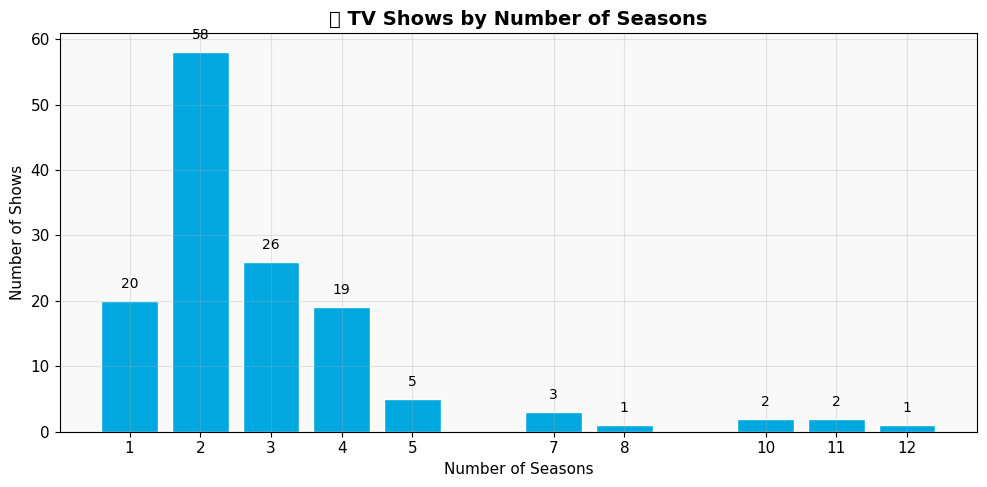

In [12]:
shows = df[(df['type'] == 'TV Show') & (df['duration_int'].notna())]
season_counts = shows['duration_int'].value_counts().sort_index().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(season_counts.index, season_counts.values,
       color=PRIME_BLUE, edgecolor='white')

for x, y in zip(season_counts.index, season_counts.values):
    ax.text(x, y + 2, str(y), ha='center', fontsize=10)

ax.set_title('📺 TV Shows by Number of Seasons', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Seasons')
ax.set_ylabel('Number of Shows')
ax.set_xticks(season_counts.index)

plt.tight_layout()
plt.savefig('../visualizations/09_tv_seasons.png', dpi=150, bbox_inches='tight')
plt.show()

## 1️⃣1️⃣ Top Directors (Excluding 'Unknown')

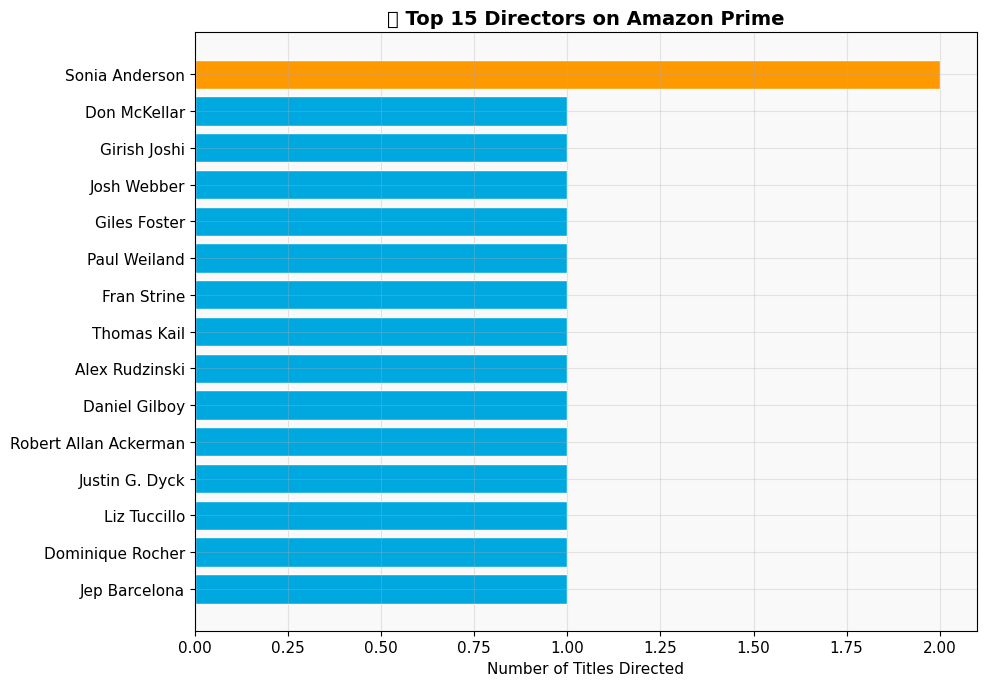

In [13]:
director_series = (df[df['director'] != 'Unknown']['director']
                   .str.split(',').explode().str.strip())
top_directors = director_series.value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#FF9900' if i == 0 else PRIME_BLUE for i in range(len(top_directors))]
ax.barh(top_directors.index[::-1], top_directors.values[::-1],
        color=colors[::-1], edgecolor='white')

ax.set_title('🎬 Top 15 Directors on Amazon Prime', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Titles Directed')
plt.tight_layout()
plt.savefig('../visualizations/10_top_directors.png', dpi=150, bbox_inches='tight')
plt.show()

## 1️⃣2️⃣ EDA Summary & Key Insights

In [14]:
movies_df = df[df['type'] == 'Movie']
shows_df  = df[df['type'] == 'TV Show']

print('='*55)
print('     📊  AMAZON PRIME VIDEO — KEY INSIGHTS')
print('='*55)
print(f'  Total titles         : {len(df)}')
print(f'  Movies               : {len(movies_df)} ({len(movies_df)/len(df)*100:.1f}%)')
print(f'  TV Shows             : {len(shows_df)} ({len(shows_df)/len(df)*100:.1f}%)')
print(f'  Peak year of adds    : {df["year_added"].value_counts().idxmax()}')
print(f'  Top country          : {df[df["primary_country"]!="Unknown"]["primary_country"].value_counts().idxmax()}')
print(f'  Top genre            : {df["primary_genre"].value_counts().idxmax()}')
print(f'  Top rating           : {df["rating"].value_counts().idxmax()}')
print(f'  Avg movie duration   : {movies_df["duration_int"].mean():.0f} minutes')
print(f'  Most common seasons  : {shows_df["duration_int"].mode()[0]:.0f} season(s)')
print('='*55)

     📊  AMAZON PRIME VIDEO — KEY INSIGHTS
  Total titles         : 155
  Movies               : 16 (10.3%)
  TV Shows             : 139 (89.7%)
  Peak year of adds    : 2021
  Top country          : United States
  Top genre            : Animation
  Top rating           : ALL
  Avg movie duration   : 85 minutes
  Most common seasons  : 2 season(s)
